In [1]:
#Lab 4

# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
from sklearn.datasets import load_breast_cancer

# Load dataset
data = load_breast_cancer()

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
# Create DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)

# Add target column
df["Outcome"] = data.target

# Display first 5 rows
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Outcome
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 569
Number of columns: 31


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [6]:
# Basic statistical summary
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Outcome
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [7]:
df.mean(numeric_only=True)

df.median(numeric_only=True)

df.std(numeric_only=True)

,0
mean radius,3.524049
mean texture,4.301036
mean perimeter,24.298981
mean area,351.914129
mean smoothness,0.014064
mean compactness,0.052813
mean concavity,0.079720
mean concave points,0.038803
mean symmetry,0.027414
mean fractal dimension,0.007060


In [8]:
# Count missing values
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
Outcome                    0
dtype: int64


In [9]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [10]:
# Fill numerical missing values with median
df.fillna(df.median(numeric_only=True), inplace=True)

print("Missing values after handling:")
print(df.isnull().sum().sum())

Missing values after handling:
0


In [11]:
# Count duplicate rows
duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

df.drop_duplicates(inplace=True)

print("Shape after removing duplicates:", df.shape)

Number of duplicate rows: 0
Shape after removing duplicates: (569, 31)


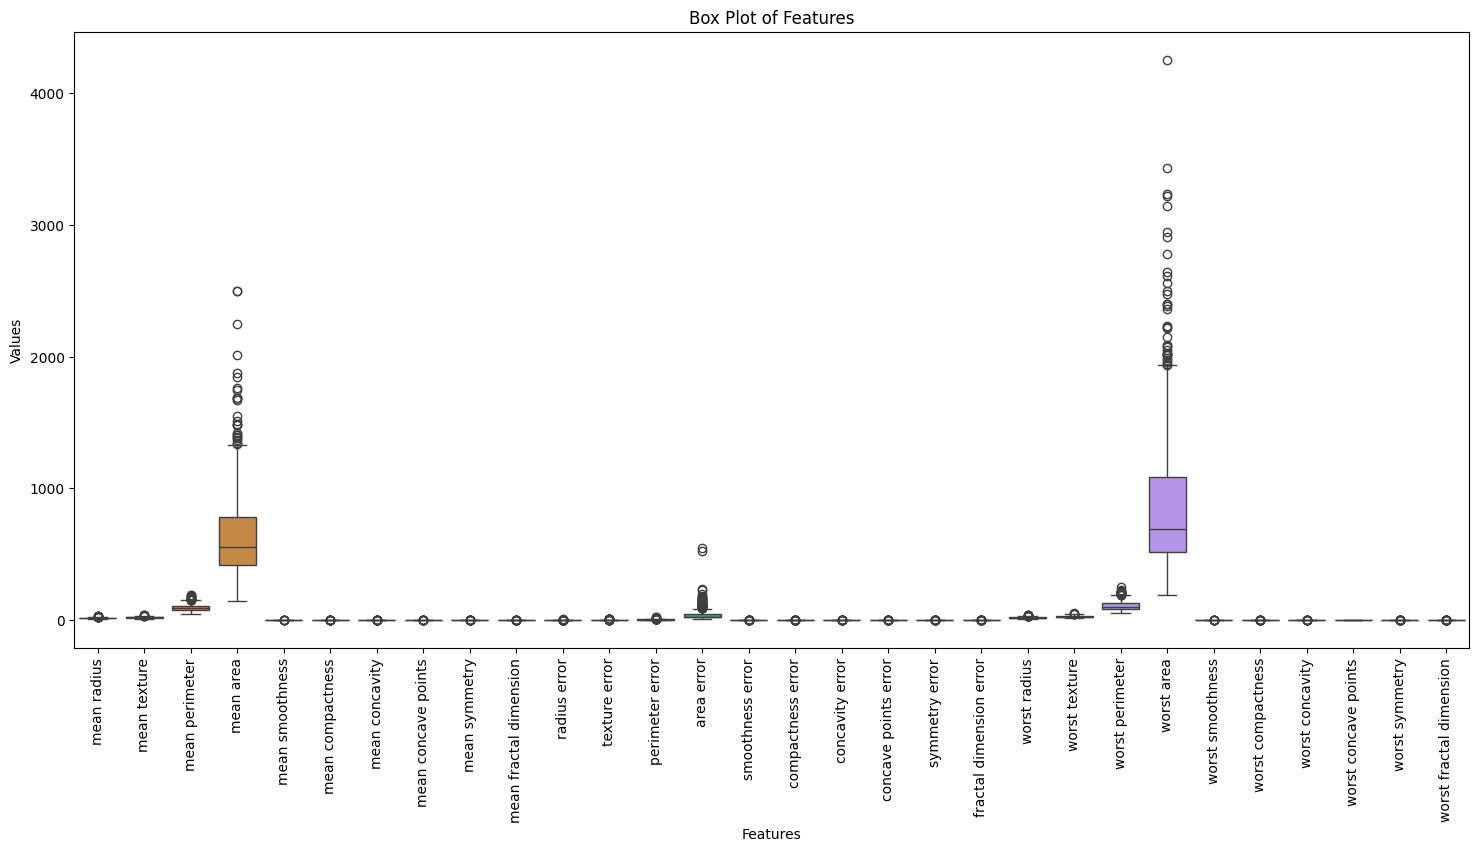

In [12]:
# Select numerical features
features = df.drop(columns=["Outcome"])

# Create boxplot
plt.figure(figsize=(18, 8))

sns.boxplot(data=features)

plt.xticks(rotation=90)
plt.title("Box Plot of Features")
plt.xlabel("Features")
plt.ylabel("Values")

plt.show()

In [13]:
Q1 = df.drop(columns=["Outcome"]).quantile(0.25)
Q3 = df.drop(columns=["Outcome"]).quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Count potential outliers
outlier_mask = (
    (df.drop(columns=["Outcome"]) < lower_bound) |
    (df.drop(columns=["Outcome"]) > upper_bound)
)

print("Potential outlier count per feature:")
print(outlier_mask.sum())

Potential outlier count per feature:
mean radius                14
mean texture                7
mean perimeter             13
mean area                  25
mean smoothness             6
mean compactness           16
mean concavity             18
mean concave points        10
mean symmetry              15
mean fractal dimension     15
radius error               38
texture error              20
perimeter error            38
area error                 65
smoothness error           30
compactness error          28
concavity error            22
concave points error       19
symmetry error             27
fractal dimension error    28
worst radius               17
worst texture               5
worst perimeter            15
worst area                 35
worst smoothness            7
worst compactness          16
worst concavity            12
worst concave points        0
worst symmetry             23
worst fractal dimension    24
dtype: int64


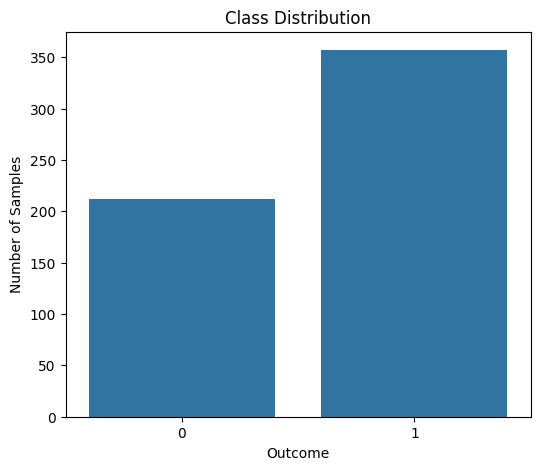

In [14]:
plt.figure(figsize=(6, 5))

sns.countplot(x="Outcome", data=df)

plt.title("Class Distribution")
plt.xlabel("Outcome")
plt.ylabel("Number of Samples")

plt.show()

In [15]:
print(df["Outcome"].value_counts())

Outcome
1    357
0    212
Name: count, dtype: int64


In [16]:
print(df["Outcome"].value_counts(normalize=True) * 100)

Outcome
1    62.741652
0    37.258348
Name: proportion, dtype: float64


In [17]:
print("Target mapping:")
for value, name in zip(data.target_names, [0, 1]):
    print(name, "=", name)

Target mapping:
0 = 0
1 = 1


In [18]:
print("0 =", data.target_names[0])
print("1 =", data.target_names[1])

0 = malignant
1 = benign


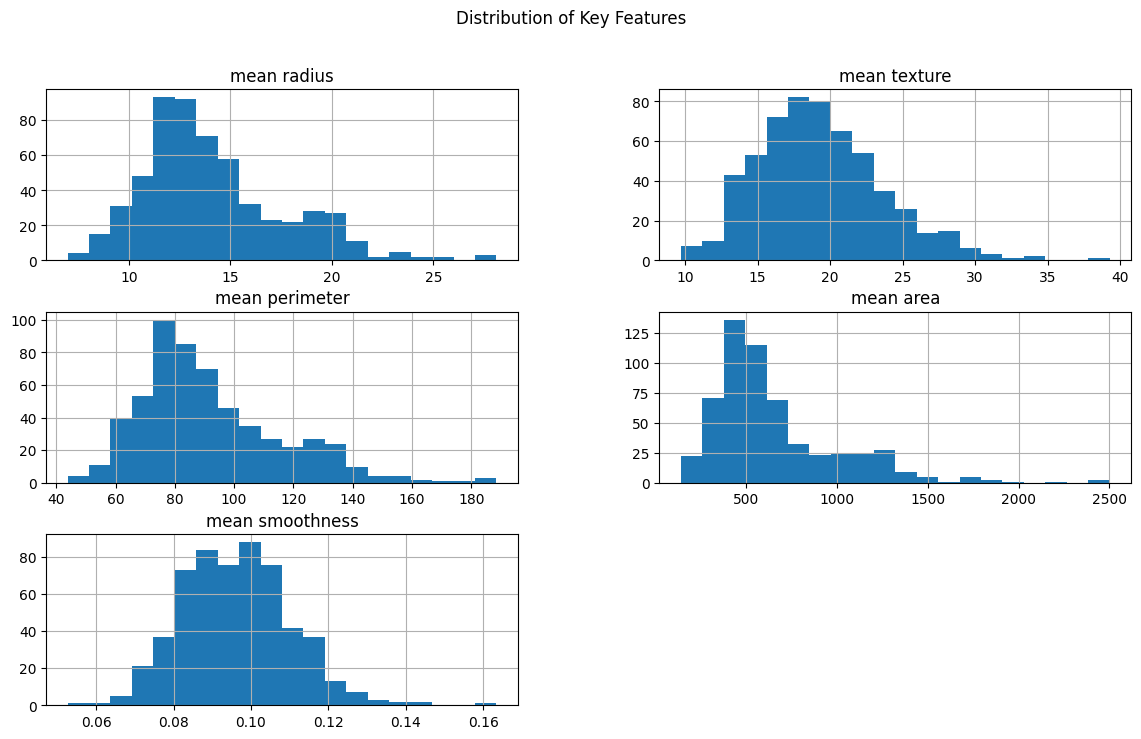

In [19]:
key_features = [
    "mean radius",
    "mean texture",
    "mean perimeter",
    "mean area",
    "mean smoothness"
]

df[key_features].hist(
    figsize=(14, 8),
    bins=20
)

plt.suptitle("Distribution of Key Features")
plt.show()

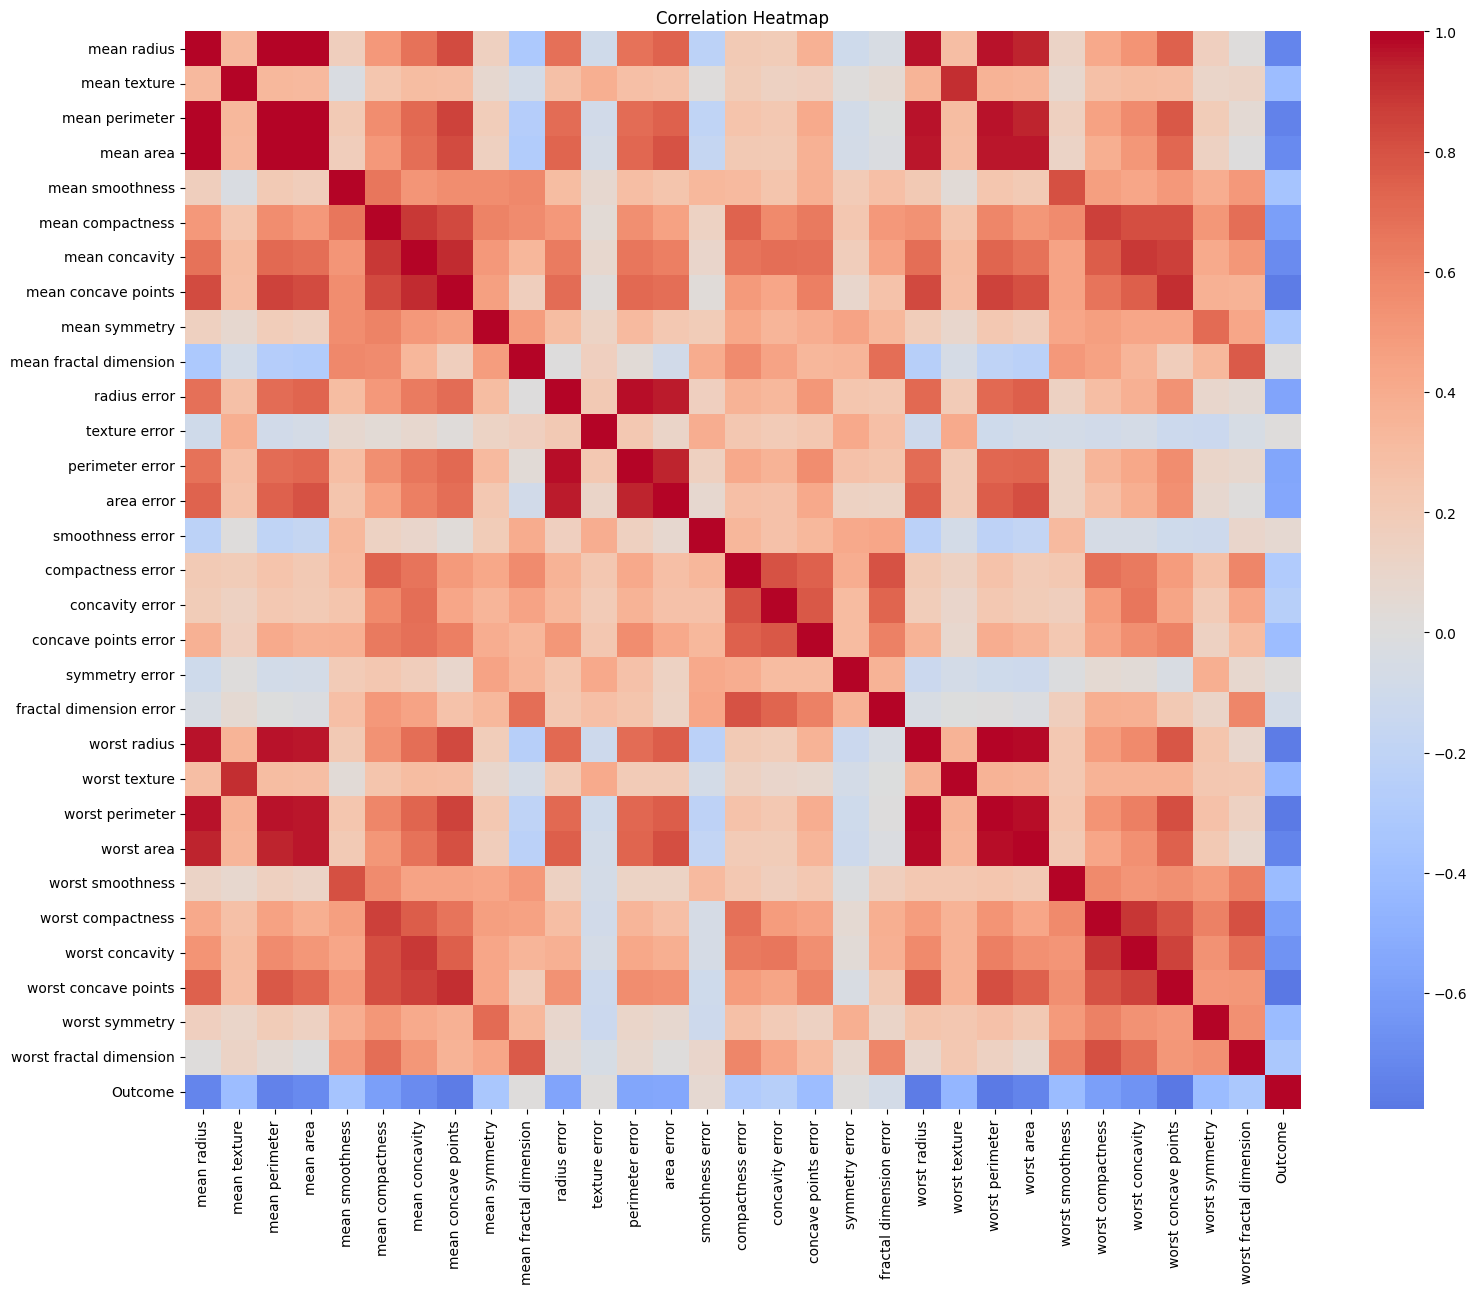

In [20]:
plt.figure(figsize=(18, 14))

correlation = df.corr(numeric_only=True)

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.show()

In [21]:
# X = input features
# y = target/output

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (569, 30)
y shape: (569,)


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


In [23]:
# Create scaler
scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data
X_test_scaled = scaler.transform(X_test)

print("Standardization completed!")

Standardization completed!


In [25]:
scaler.fit_transform(X_train)

scaler.transform(X_test)

array([[ 1.56851278,  2.16401585,  1.74286587, ...,  1.20214432,
        -0.14043064,  0.90036171],
       [-0.84027641, -0.5970672 , -0.8741735 , ..., -1.10124064,
        -0.81429139, -0.71323608],
       [-0.07072262,  1.19138742,  0.03202768, ...,  0.57255843,
         1.14997397,  1.86841162],
       ...,
       [ 0.3583966 , -0.44935493,  0.48264098, ...,  1.63386036,
         0.54117564,  1.91191948],
       [-0.41401799,  1.07321761, -0.42314565, ...,  0.06139464,
        -0.1280378 ,  0.64747227],
       [-0.6829327 , -0.69932953, -0.66607058, ..., -0.23615965,
        -0.16211811, -0.20147486]])

In [26]:
print("Mean of first 5 standardized features:")
print(X_train_scaled[:, :5].mean(axis=0))

print("\nStandard deviation:")
print(X_train_scaled[:, :5].std(axis=0))

Mean of first 5 standardized features:
[-2.92806072e-16  6.24652955e-16 -1.62995380e-16 -1.71779562e-16
  6.24652955e-17]

Standard deviation:
[1. 1. 1. 1. 1.]


In [27]:
# Create Logistic Regression model
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train model
model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [28]:
# Predict class labels
y_pred = model.predict(X_test_scaled)

print("Predictions:")
print(y_pred[:20])

Predictions:
[0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 1 1]


In [29]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.9824561403508771
Accuracy (%): 98.24561403508771


In [30]:
precision = precision_score(
    y_test,
    y_pred,
    average=None
)

print("Precision for class 0:", precision[0])
print("Precision for class 1:", precision[1])

Precision for class 0: 0.9761904761904762
Precision for class 1: 0.9861111111111112


In [31]:
recall = recall_score(
    y_test,
    y_pred,
    average=None
)

print("Recall for class 0:", recall[0])
print("Recall for class 1:", recall[1])

Recall for class 0: 0.9761904761904762
Recall for class 1: 0.9861111111111112


In [32]:
f1 = f1_score(
    y_test,
    y_pred,
    average=None
)

print("F1-score for class 0:", f1[0])
print("F1-score for class 1:", f1[1])

F1-score for class 0: 0.9761904761904762
F1-score for class 1: 0.9861111111111112


In [33]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Malignant", "Benign"]
))

              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



Confusion Matrix:
[[41  1]
 [ 1 71]]


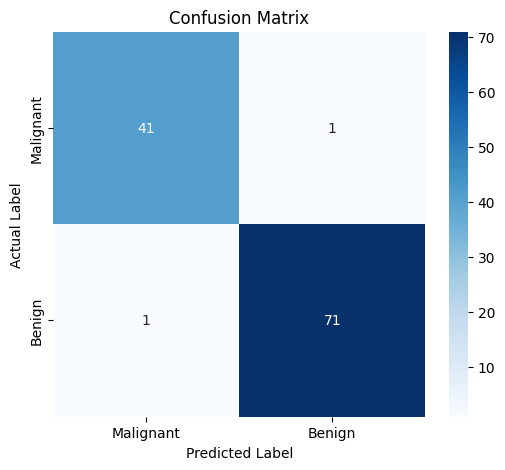

In [34]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Malignant", "Benign"],
    yticklabels=["Malignant", "Benign"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()

In [35]:
# Probability of class 1
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Calculate ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

In [36]:
auc_score = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", auc_score)

ROC-AUC Score: 0.9953703703703703


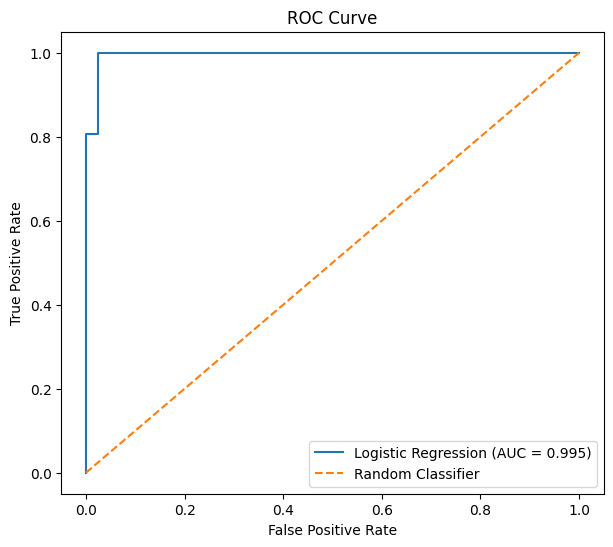

In [37]:
plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc_score:.3f})"
)

# Random classifier line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

In [38]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

results.head(20)

,Actual,Predicted
0,0,0
1,1,1
2,0,0
3,1,1
4,0,0
5,1,1
6,1,1
7,0,0
8,0,0
9,0,0
